# Costumer Churn Prediction

## 1. Project Goal

The goal of this project is to build a machine learning classification model that predicts whether a customer will churn.

Customer churn means that a customer stops using a company’s service. Predicting churn can help a company understand which customers are at risk of leaving.

## 2. Import Libraries

In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,recall_score,f1_score

## 3. Load Dataset

In [4]:
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## 4. Basic Data Exploration

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.shape

(7043, 21)

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## 5. Data Cleaning

In this section, the dataset is prepared for machine learning. The `customerID` column is removed, `TotalCharges` is converted from text to numeric format, and the target column `Churn` is converted from `Yes/No` values into `1/0`.

In [9]:
df_clean = df.copy()
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors='coerce')
df_clean = df_clean.drop(columns=["customerID"])
df_clean["TotalCharges"].isnull().sum()

np.int64(11)

In [11]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(df_clean["TotalCharges"].median())
df_clean["TotalCharges"].isnull().sum()
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [12]:
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})
df_clean["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## 6. Feature Selection

In this section, the input features and target column are separated. The target column is `Churn`, and all remaining useful customer columns are used as model features.

In [15]:
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [16]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [17]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [19]:
X_encoded.shape

(7043, 30)

In [20]:
X_encoded.dtypes.sort_values()

OnlineBackup_No internet service            bool
PaymentMethod_Credit card (automatic)       bool
PaperlessBilling_Yes                        bool
Contract_Two year                           bool
Contract_One year                           bool
StreamingMovies_Yes                         bool
StreamingMovies_No internet service         bool
StreamingTV_Yes                             bool
StreamingTV_No internet service             bool
TechSupport_Yes                             bool
TechSupport_No internet service             bool
DeviceProtection_Yes                        bool
DeviceProtection_No internet service        bool
OnlineBackup_Yes                            bool
PaymentMethod_Mailed check                  bool
OnlineSecurity_Yes                          bool
OnlineSecurity_No internet service          bool
InternetService_No                          bool
InternetService_Fiber optic                 bool
MultipleLines_Yes                           bool
MultipleLines_No pho

In [21]:
X_encoded = X_encoded.astype(int)
X_encoded.dtypes.sort_values()

SeniorCitizen                            int64
PaymentMethod_Credit card (automatic)    int64
PaperlessBilling_Yes                     int64
Contract_Two year                        int64
Contract_One year                        int64
StreamingMovies_Yes                      int64
StreamingMovies_No internet service      int64
StreamingTV_Yes                          int64
StreamingTV_No internet service          int64
TechSupport_Yes                          int64
TechSupport_No internet service          int64
DeviceProtection_Yes                     int64
DeviceProtection_No internet service     int64
OnlineBackup_Yes                         int64
OnlineBackup_No internet service         int64
OnlineSecurity_Yes                       int64
OnlineSecurity_No internet service       int64
InternetService_No                       int64
InternetService_Fiber optic              int64
MultipleLines_Yes                        int64
MultipleLines_No phone service           int64
PhoneService_

## Save Processed Dataset

The cleaned and encoded dataset is saved into the `data/processed/` folder. This makes it possible to reuse the model-ready data without repeating the cleaning and encoding steps.

In [22]:
model_ready_data = X_encoded.copy()
model_ready_data["Churn"] = y
model_ready_data.to_csv('../data/processed/model_ready_data.csv', index=False)

## 7. Train/Test Split

In this section, the dataset is split into training and testing sets. The training set is used to train the models, and the test set is used to evaluate how well the models perform on unseen data.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)  
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Training set shape: (5634, 30)
Test set shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


In [24]:
print("Training set class distribution:\n", y_train.value_counts(normalize=True))
print("Test set class distribution:\n", y_test.value_counts(normalize=True))

Training set class distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Test set class distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## 8. Model 1: Logistic Regression Baseline

Logistic Regression is used as the baseline classification model. A baseline model gives us a simple starting result that we can compare with a more advanced model later.

In [27]:
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
log_predictions = log_model.predict(X_test)
log_predictions[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [29]:
log_accuracy = log_model.score(X_test, y_test)
print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.8069552874378992


In [31]:
log_conf_matrix = confusion_matrix(y_test, log_predictions)
log_conf_matrix

array([[927, 108],
       [164, 210]])

In [32]:
log_classification_report = classification_report(y_test, log_predictions)
print("Logistic Regression Classification Report:\n", log_classification_report)

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



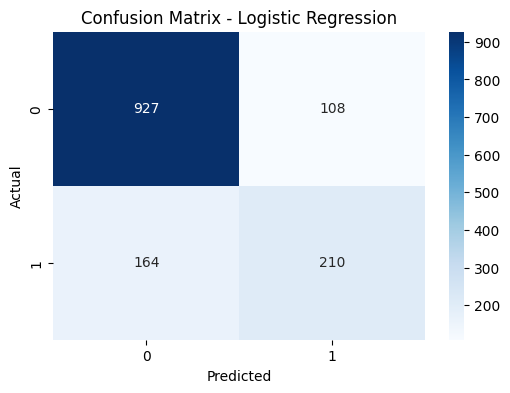

In [33]:
plt.figure(figsize=(6,4))
sns.heatmap(log_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The Logistic Regression baseline model achieved about 81% accuracy. It performed well at identifying customers who did not churn, with a recall of 0.90 for class 0. However, it was weaker at identifying customers who churned, with a recall of 0.56 for class 1. Since churn prediction focuses on finding customers who are likely to leave, improving recall for the churn class will be important in the next model.

## 9. Model 2: Random Forest Classifier

A Random Forest Classifier is used as the second model. Random Forest combines many decision trees to make more stable predictions. This model will be compared with the Logistic Regression baseline.

In [53]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [54]:
rf_predictions = rf_model.predict(X_test)
rf_predictions[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [55]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7899219304471257


In [56]:
rf_conf_matrix = confusion_matrix(y_test, rf_predictions)
rf_conf_matrix

array([[926, 109],
       [187, 187]])

In [57]:
rf_classification_report = classification_report(y_test, rf_predictions)
print("Random Forest Classification Report:\n", rf_classification_report)

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



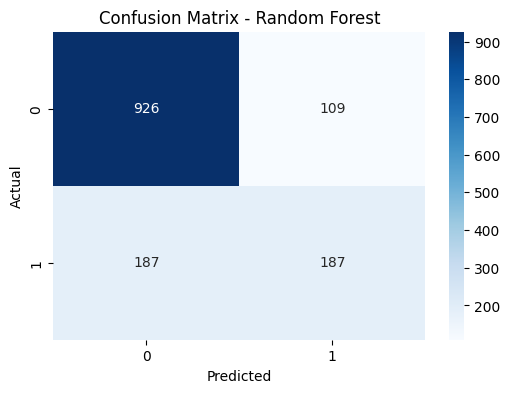

In [59]:
plt.figure(figsize=(6,4))
sns.heatmap(rf_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The Random Forest Classifier achieved an accuracy of about 79%. It performed well at predicting customers who did not churn, but it was weaker at identifying customers who actually churned. The recall for churn customers was 0.50, meaning the model found only half of the actual churn cases. In this version of the project, Logistic Regression performed better overall than Random Forest.

## 10. Feature Importance

In this section, feature importance from the Random Forest model is analyzed. Feature importance helps identify which customer features were most useful for predicting churn.

In [58]:
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
3,TotalCharges,0.190727
1,tenure,0.181784
2,MonthlyCharges,0.133352
28,PaymentMethod_Electronic check,0.042992
10,InternetService_Fiber optic,0.039229
4,gender_Male,0.031135
25,Contract_Two year,0.030598
13,OnlineSecurity_Yes,0.029206
26,PaperlessBilling_Yes,0.028160
5,Partner_Yes,0.025237


C:\Users\user\AppData\Local\Temp\ipykernel_15512\1734256783.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')


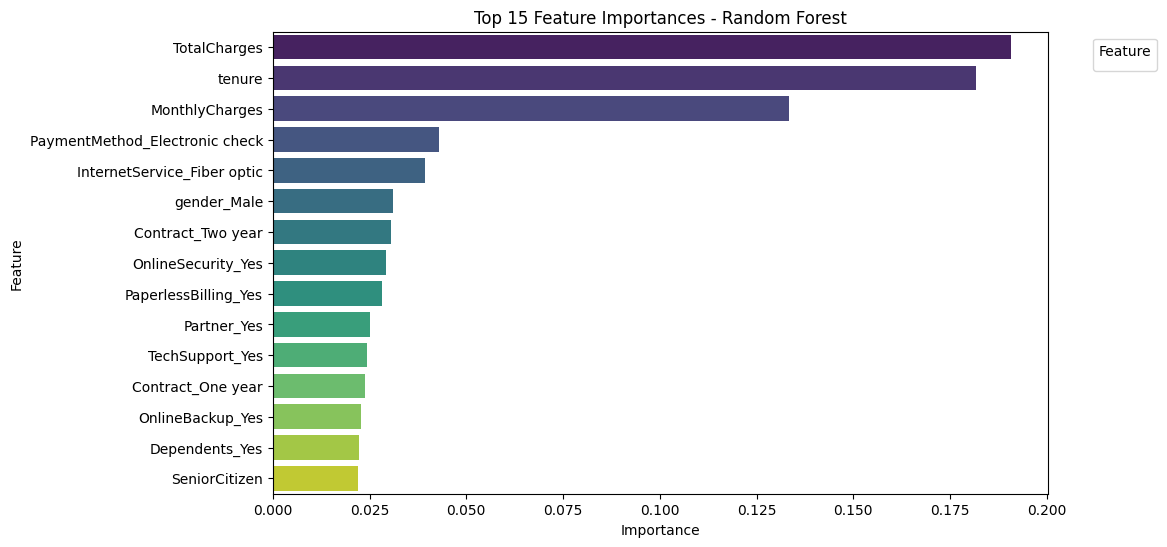

In [60]:
top_features = feature_importance.head(15)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top_features,hue='Feature', palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The Random Forest feature importance analysis shows that `TotalCharges`, `tenure`, and `MonthlyCharges` were the most important features for predicting customer churn. Payment method and internet service type also appeared among the top features. This suggests that customer payment history, customer relationship length, monthly billing amount, and service type are useful signals for churn prediction.

## 11. Model Comparison

In this section, the Logistic Regression baseline model and Random Forest Classifier are compared using accuracy and classification performance.

In [62]:
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_accuracy, rf_accuracy],
    'Churn Recall':[
        recall_score(y_test, log_predictions),
        recall_score(y_test, rf_predictions)
    ],
    'F1_score':[
        f1_score(y_test, log_predictions),
        f1_score(y_test, rf_predictions)
    ]
})

model_results

,Model,Accuracy,Churn Recall,F1_score
0,Logistic Regression,0.806955,0.561497,0.606936
1,Random Forest,0.789922,0.500000,0.558209


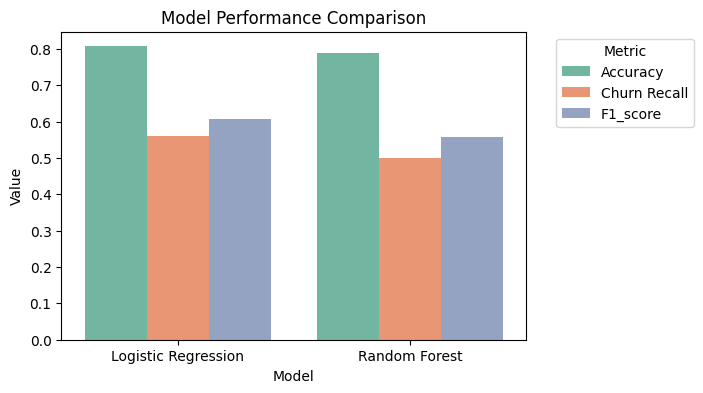

In [63]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=model_results.melt(id_vars='Model', value_vars=['Accuracy', 'Churn Recall', 'F1_score'], var_name='Metric', value_name='Value'),
    x='Model', y='Value', hue='Metric', palette='Set2'
)
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Value')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Logistic Regression performed slightly better than Random Forest in this project. It achieved higher accuracy, higher churn recall, and a higher churn F1-score. Although Random Forest is usually a stronger model, it did not outperform Logistic Regression in this version. This shows that a more complex model is not always better, and model performance should always be checked with evaluation metrics.

## 12. Final Findings

This project focused on predicting customer churn using machine learning classification models.

Key findings:

- The dataset contains 7,043 customers and 21 original columns.
- The target column is `Churn`, where `0` means no churn and `1` means churn.
- The dataset had no normal missing values, but `TotalCharges` was stored as text and needed to be converted into a numeric column.
- The `customerID` column was removed because it is only an identifier and does not help the model learn customer behavior.
- Categorical features were converted into numeric format using one-hot encoding.
- The processed, model-ready dataset was saved into the `data/processed/` folder.
- Logistic Regression achieved about 81% accuracy.
- Random Forest achieved about 79% accuracy.
- Logistic Regression performed better than Random Forest in this version of the project.
- Logistic Regression had better churn recall and churn F1-score than Random Forest.
- Feature importance from Random Forest showed that `TotalCharges`, `tenure`, and `MonthlyCharges` were among the most important features.
- The most important business lesson is that customer payment history, relationship length, monthly billing amount, contract type, and service type can be useful signals for churn prediction.

Overall, this project showed the full customer churn classification workflow: data loading, data cleaning, feature encoding, train/test splitting, model training, evaluation, feature importance analysis, model comparison, and final interpretation.